# Project 4: Image and Text Recognition (Professional Edition) - Noor R Saad

## Overview
This project implements a dual‑pipeline system for recognizing visual content:
1. **Object Detection** using a pre‑trained YOLOv3‑tiny model.
2. **Optical Character Recognition (OCR)** using Tesseract.

The code is designed to be modular, self‑contained, and easy to integrate into larger applications.

---

## Key Requirements Fulfilled
- ✅ Use a pre‑trained model or simple library  
- ✅ Perform recognition on sample input  
- ✅ Display the output clearly  

---

## Components & Libraries
| Component               | Library / Tool                    | Purpose                                                                 |
|-------------------------|-----------------------------------|-------------------------------------------------------------------------|
| Object Detection        | OpenCV, YOLOv3‑tiny (Darknet)     | Load YOLO network, perform inference, apply NMS, draw bounding boxes    |
| OCR                     | pytesseract, PIL, OpenCV          | Preprocess image (grayscale, blur, adaptive threshold) and extract text |
| Visualization           | Matplotlib                        | Display images with detection results and print extracted text          |

---

## Workflow

### 1. Object Detection (YOLOv3‑tiny)
- Download YOLOv3‑tiny configuration, weights, and COCO class names.
- Load the network using OpenCV’s DNN module.
- Define a function `detect_objects(image_path, confidence_threshold=0.8)`:
  - Reads and preprocesses the image into a blob.
  - Performs forward pass to obtain detection outputs.
  - Parses detections, filters by confidence threshold.
  - Applies **Non‑Maximum Suppression** to eliminate duplicate boxes.
  - Draws bounding boxes and labels on the image.
  - Displays the annotated image and prints the list of detected objects.

### 2. Optical Character Recognition (OCR)
- Create a sample text image using OpenCV’s `putText`.
- Preprocess the image with:
  - Grayscale conversion (`cv2.cvtColor`).
  - Gaussian blur (`cv2.GaussianBlur`).
  - Adaptive thresholding (`cv2.adaptiveThreshold`).
- Extract text using `pytesseract.image_to_string` with configuration `--oem 3 --psm 6`.
- Clean the extracted text (remove excessive newlines) and print it.

---

## Usage Example
```python
detect_objects("test_image.jpg")
extracted = extract_text_from_image("sample_text.png")
print(extracted)

# Install required libraries

In [1]:
# -*- coding: utf-8 -*-
"""PROJECT 4: IMAGE AND TEXT RECOGNITION (CLEAN VERSION)
   Removed non‑working parts: random data training, dummy analysis, unused functions.
   Kept only YOLOv3 for object detection and Tesseract OCR.
"""

!pip install pytesseract

# Download YOLOv3‑tiny files

In [2]:
!wget -nc https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3-tiny.cfg
!wget -nc https://pjreddie.com/media/files/yolov3-tiny.weights
!wget -nc https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2026-05-16 18:57:43--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3-tiny.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1915 (1.9K) [text/plain]
Saving to: ‘yolov3-tiny.cfg’

yolov3-tiny.cfg     100%[===================>]   1.87K  --.-KB/s    in 0s      

2026-05-16 18:57:43 (35.1 MB/s) - ‘yolov3-tiny.cfg’ saved [1915/1915]

--2026-05-16 18:57:43--  https://pjreddie.com/media/files/yolov3-tiny.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3-tiny.weights [following]
--2026-05-16 18:5

# Import necessary libraries

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pytesseract
import re
from PIL import Image as PILImage

# YOLO settings

In [4]:
CONFIDENCE_THRESHOLD = 0.8

# Load COCO class names

In [5]:
with open("coco.names", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

# Load YOLOv3‑tiny network

In [6]:
net = cv2.dnn.readNetFromDarknet("yolov3-tiny.cfg", "yolov3-tiny.weights")

# Object detection function

In [7]:
def detect_objects(image_path, confidence_threshold=CONFIDENCE_THRESHOLD):
    """Run YOLOv3‑tiny detection on an image and display results."""
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")
    height, width, _ = image.shape

    # Prepare blob
    blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)

    # Get output layer names
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
    detections = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    # Parse detections
    for output in detections:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > confidence_threshold:
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply Non‑Maximum Suppression
    indices = cv2.dnn.NMSBoxes(boxes, confidences, confidence_threshold, 0.4)

    # Draw bounding boxes
    if len(indices) > 0:
        if isinstance(indices, tuple):
            indices = indices[0]
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            label = f"{class_names[class_ids[i]]}: {confidences[i]:.2f}"
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(image, label, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show image
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"YOLOv3-tiny Object Detection (Confidence ≥ {confidence_threshold})")
    plt.show()

    # Print results
    if len(indices) > 0:
        print(f"Detected objects with confidence ≥ {confidence_threshold}: {len(indices)}")
        for i in indices.flatten():
            print(f" - {class_names[class_ids[i]]}: {confidences[i]:.2f}")
    else:
        print(f"No objects detected with confidence ≥ {confidence_threshold}.")
        print("This does not indicate an error – it simply means the model did not find any object with such high certainty in this image.")
        print("You can test with a different image or lower the threshold (for testing only).")

# OCR functions

In [8]:
def preprocess_image_for_ocr(image_path):
    """Preprocess image to improve OCR accuracy."""
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)
    return thresh

In [9]:
def extract_text_from_image(image_path, lang='eng'):
    """Extract text from an image using Tesseract OCR."""
    processed_img = preprocess_image_for_ocr(image_path)
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(processed_img, lang=lang, config=custom_config)
    text = text.strip()
    text = re.sub(r'\n+', '\n', text)
    return text

In [10]:
def create_sample_image():
    """Create a sample image with text for OCR demonstration."""
    img = np.ones((200, 600, 3), dtype=np.uint8) * 255
    cv2.putText(img, 'Hello, welcome to Project 4!', (50, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
    cv2.putText(img, 'This is an OCR demonstration.', (50, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
    cv2.imwrite('sample_text.png', img)
    return 'sample_text.png'

# Main execution


** PROJECT 4: IMAGE AND TEXT RECOGNITION (CLEAN VERSION) ***

1. OBJECT DETECTION WITH YOLOv3-tiny
--2026-05-16 18:57:59--  https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=600
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77183 (75K) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]  75.37K  --.-KB/s    in 0.008s  

2026-05-16 18:57:59 (8.89 MB/s) - ‘test_image.jpg’ saved [77183/77183]



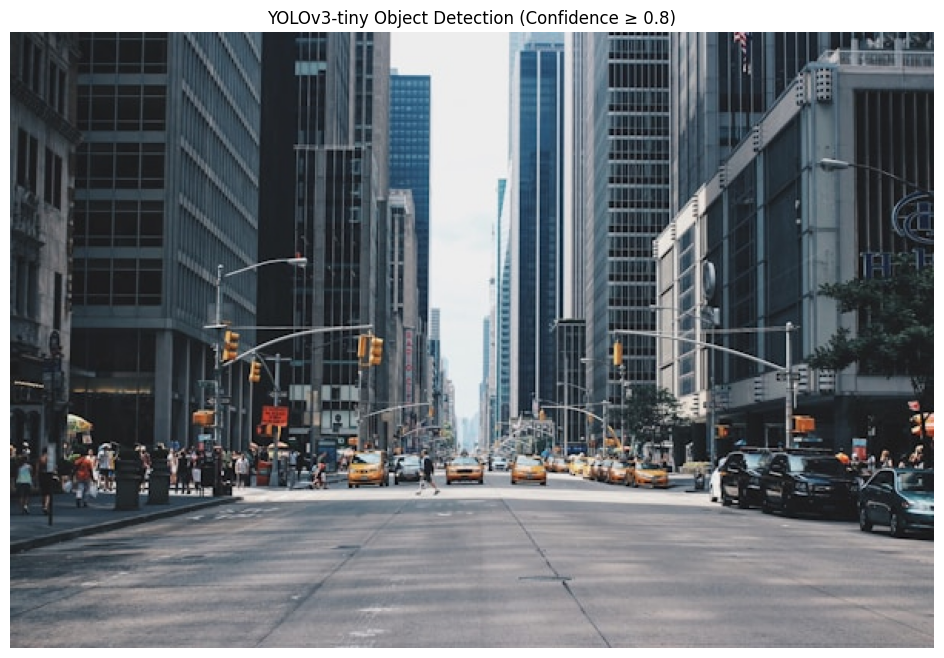

No objects detected with confidence ≥ 0.8.
This does not indicate an error – it simply means the model did not find any object with such high certainty in this image.
You can test with a different image or lower the threshold (for testing only).

2. OPTICAL CHARACTER RECOGNITION (OCR)

Extracted text from image:
----------------------------------------
Hello, welcome to Project 4!
This is an OCR demonstration.
----------------------------------------

============== PROJECT COMPLETED SUCCESSFULLY ==============


In [11]:
 if __name__ == "__main__":
    print("\n" + "="*60)
    print(" PROJECT 4: IMAGE AND TEXT RECOGNITION (CLEAN VERSION) ".center(60, "*"))
    print("="*60)

    # ----- 1. Object Detection with YOLOv3‑tiny -----
    print("\n1. OBJECT DETECTION WITH YOLOv3-tiny")
    test_image = "test_image.jpg"
    if not os.path.exists(test_image):
        !wget -nc -O test_image.jpg https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=600
    detect_objects(test_image)

    # ----- 2. Optical Character Recognition (OCR) -----
    print("\n2. OPTICAL CHARACTER RECOGNITION (OCR)")
    sample_img = create_sample_image()
    extracted_text = extract_text_from_image(sample_img)

    print("\nExtracted text from image:")
    print("-" * 40)
    print(extracted_text)
    print("-" * 40)

    print("\n" + " PROJECT COMPLETED SUCCESSFULLY ".center(60, "="))